# 03 — Classical Models vs IndoBERT

This notebook combines the saved results from:

- `01_classical_models`
- `02_indoBERT_final`

It creates:

1. a combined comparison table,
2. fair ranking based on **test macro F1**,
3. metric comparison charts,
4. confusion matrices,
5. IndoBERT training-history charts,
6. a final summary,
7. CSV and JSON comparison files.

> Run notebooks 01 and 02 first so their result files are available in Google Drive.

### Robust file loading

This version searches recursively for the IndoBERT summary. If the summary CSV
is unavailable, it reconstructs test metrics from the saved confusion matrices
and retrieves validation metrics from `trainer_state.json`. Training does not
need to be repeated when those saved files are still available.


## 1. Imports

In [31]:
import json
import math
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay

warnings.filterwarnings("ignore")

print("Imports OK")

Imports OK


## 2. Project Paths

In [32]:
# Mount Google Drive when the notebook runs in Colab.
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as error:
    print("Drive mount skipped:", error)

PROJECT_DIR = Path("/content/drive/MyDrive/NLPAOL_V3")

SETTING_LABELS = {
    "indobert_imbalance": "Imbalance",
    "indobert_balance": "Balance",
    "indobert_imbalance_augment": "Imbalance + Augment",
    "indobert_balance_augment": "Balance + Augment",
}


def unique_paths(paths):
    seen = set()
    result = []

    for path in paths:
        path = Path(path)
        key = str(path)

        if key not in seen:
            seen.add(key)
            result.append(path)

    return result


def first_existing(candidates):
    for path in unique_paths(candidates):
        if path.exists():
            return path

    return None


if not PROJECT_DIR.exists():
    raise FileNotFoundError(
        f"Project folder was not found: {PROJECT_DIR}\n"
        "Check the folder name in Google Drive."
    )


# ============================================================
# Notebook 01 output
# ============================================================

classical_candidates = [
    PROJECT_DIR
    / "outputs"
    / "classical_models_all_agree"
    / "classical_results.json",
]

classical_candidates.extend(
    PROJECT_DIR.rglob("classical_results.json")
)

CLASSICAL_JSON = first_existing(classical_candidates)


# ============================================================
# Notebook 02 summary CSV
# ============================================================

summary_candidates = [
    # Matches notebook 02's actual OUTPUT_ROOT / RESULTS_DIR layout
    PROJECT_DIR
    / "output_indobert_final"
    / "results"
    / "indobert_experiment_summary.csv",

    PROJECT_DIR
    / "output_indobert_final"
    / "results"
    / "indobert_all_experiments.csv",

    # Older/alternate layouts kept as fallbacks
    PROJECT_DIR
    / "outputs_indobert_exact_pipeline"
    / "results"
    / "indobert_experiment_summary.csv",

    PROJECT_DIR
    / "outputs_indobert_exact_pipeline"
    / "results"
    / "indobert_all_experiments.csv",

    PROJECT_DIR
    / "outputs_indobert"
    / "results"
    / "indobert_experiment_summary.csv",

    PROJECT_DIR
    / "outputs_indobert"
    / "final_results"
    / "indobert_all_experiments.csv",
]

summary_candidates.extend(
    PROJECT_DIR.rglob("indobert_experiment_summary.csv")
)
summary_candidates.extend(
    PROJECT_DIR.rglob("indobert_all_experiments.csv")
)

INDOBERT_CSV = first_existing(summary_candidates)


# ============================================================
# IndoBERT result folder
# ============================================================

result_dir_candidates = [
    PROJECT_DIR
    / "output_indobert_final"
    / "results",

    PROJECT_DIR
    / "outputs_indobert_exact_pipeline"
    / "results",

    PROJECT_DIR
    / "outputs_indobert"
    / "final_results",
]

if INDOBERT_CSV is not None:
    result_dir_candidates.insert(
        0,
        INDOBERT_CSV.parent,
    )

for cm_file in PROJECT_DIR.rglob(
    "indobert_*_confusion_matrix.csv"
):
    result_dir_candidates.append(
        cm_file.parent
    )

INDOBERT_RESULTS_DIR = first_existing(
    result_dir_candidates
)

if INDOBERT_RESULTS_DIR is None:
    INDOBERT_RESULTS_DIR = (
        PROJECT_DIR
        / "output_indobert_final"
        / "results"
    )


# ============================================================
# IndoBERT checkpoint root
# ============================================================

checkpoint_candidates = [
    PROJECT_DIR
    / "output_indobert_final"
    / "checkpoints",

    PROJECT_DIR
    / "outputs_indobert_exact_pipeline"
    / "checkpoints",

    PROJECT_DIR
    / "outputs_indobert"
    / "indobert_model",
]

for experiment in SETTING_LABELS:
    for experiment_dir in PROJECT_DIR.rglob(
        experiment
    ):
        if experiment_dir.is_dir():
            checkpoint_candidates.append(
                experiment_dir.parent
            )

INDOBERT_CHECKPOINT_ROOT = first_existing(
    checkpoint_candidates
)

if INDOBERT_CHECKPOINT_ROOT is None:
    INDOBERT_CHECKPOINT_ROOT = (
        PROJECT_DIR
        / "output_indobert_final"
        / "checkpoints"
    )


# ============================================================
# Comparison output
# ============================================================

OUTPUT_DIR = (
    PROJECT_DIR
    / "outputs_compare_modelresults"
)
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


print("PROJECT_DIR              :", PROJECT_DIR)
print("PROJECT_DIR exists       :", PROJECT_DIR.exists())
print()
print("CLASSICAL_JSON           :", CLASSICAL_JSON)
print(
    "CLASSICAL_JSON exists    :",
    CLASSICAL_JSON is not None
    and CLASSICAL_JSON.exists(),
)
print()
print("INDOBERT_CSV             :", INDOBERT_CSV)
print(
    "INDOBERT_CSV exists      :",
    INDOBERT_CSV is not None
    and INDOBERT_CSV.exists(),
)
print("INDOBERT_RESULTS_DIR     :", INDOBERT_RESULTS_DIR)
print(
    "INDOBERT_RESULTS exists  :",
    INDOBERT_RESULTS_DIR.exists(),
)
print("INDOBERT_CHECKPOINT_ROOT :", INDOBERT_CHECKPOINT_ROOT)
print(
    "CHECKPOINT_ROOT exists   :",
    INDOBERT_CHECKPOINT_ROOT.exists(),
)
print("OUTPUT_DIR               :", OUTPUT_DIR)

if INDOBERT_CSV is None:
    print()
    print(
        "Summary CSV was not found. "
        "Metrics will be reconstructed from saved "
        "confusion matrices and trainer_state.json."
    )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_DIR              : /content/drive/MyDrive/NLPAOL_V3
PROJECT_DIR exists       : True

CLASSICAL_JSON           : /content/drive/MyDrive/NLPAOL_V3/outputs/classical_models_all_agree/classical_results.json
CLASSICAL_JSON exists    : True

INDOBERT_CSV             : /content/drive/MyDrive/NLPAOL_V3/output_indobert_final/results/indobert_experiment_summary.csv
INDOBERT_CSV exists      : True
INDOBERT_RESULTS_DIR     : /content/drive/MyDrive/NLPAOL_V3/output_indobert_final/results
INDOBERT_RESULTS exists  : True
INDOBERT_CHECKPOINT_ROOT : /content/drive/MyDrive/NLPAOL_V3/output_indobert_final/checkpoints
CHECKPOINT_ROOT exists   : True
OUTPUT_DIR               : /content/drive/MyDrive/NLPAOL_V3/outputs_compare_modelresults


## 3. Helper Functions

In [33]:
def safe_float(value):
    try:
        if value is None:
            return None
        value = float(value)
        if math.isnan(value):
            return None
        return value
    except (TypeError, ValueError):
        return None


def first_value(mapping, keys):
    for key in keys:
        value = safe_float(mapping.get(key))
        if value is not None:
            return value
    return None


def validate_cm(cm):
    if cm is None:
        return None

    array = np.asarray(cm)

    if array.shape != (2, 2):
        return None

    return array.astype(int).tolist()


def load_confusion_matrix(path):
    path = Path(path)

    if not path.exists():
        return None

    try:
        frame = pd.read_csv(path, index_col=0)
        return validate_cm(frame.values)
    except Exception:
        return None


def short_name(model_name):
    return (
        str(model_name)
        .replace("Multinomial Naive Bayes", "MNB")
        .replace("Logistic Regression", "LR")
        .replace("SVM (LinearSVC + Calibrated)", "SVM")
        .replace("IndoBERT (", "")
        .replace(")", "")
    )


def safe_filename(value):
    value = re.sub(r"[^A-Za-z0-9_-]+", "_", str(value))
    return value.strip("_").lower()


def format_score(value):
    value = safe_float(value)
    return f"{value:.4f}" if value is not None else "N/A"


def json_ready(value):
    if isinstance(value, dict):
        return {key: json_ready(item) for key, item in value.items()}
    if isinstance(value, list):
        return [json_ready(item) for item in value]
    if isinstance(value, tuple):
        return [json_ready(item) for item in value]
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if pd.isna(value):
        return None
    return value


print("Helper functions OK")

Helper functions OK


## 4. Load Classical Model Results

In [34]:
if CLASSICAL_JSON is None or not CLASSICAL_JSON.exists():
    raise FileNotFoundError(
        "classical_results.json was not found. "
        "Run notebook 01 first and check its OUTPUT_DIR."
    )

with open(CLASSICAL_JSON, "r", encoding="utf-8") as file:
    classical_results = json.load(file)

if not isinstance(classical_results, list) or not classical_results:
    raise ValueError("The classical result file is empty or has an invalid format.")

classical_preview = pd.DataFrame(classical_results)

display_columns = [
    column
    for column in [
        "model",
        "accuracy",
        "precision_macro",
        "recall_macro",
        "f1_macro",
        "auc_roc",
        "inference_ms_per_sample",
    ]
    if column in classical_preview.columns
]

print(f"Loaded {len(classical_results)} classical models")
display(classical_preview[display_columns])

Loaded 3 classical models


,model,accuracy,precision_macro,recall_macro,f1_macro,auc_roc,inference_ms_per_sample
0,Multinomial Naive Bayes,0.8721,0.8808,0.8485,0.8597,0.9401,0.0016
1,Logistic Regression,0.9081,0.9109,0.8942,0.9011,0.9614,0.0009
2,SVM (LinearSVC + Calibrated),0.9116,0.9165,0.8965,0.9046,0.9611,0.0082


## 5. Load IndoBERT Results

In [35]:
def find_experiment_file(
    experiment,
    suffix,
):
    expected = (
        INDOBERT_RESULTS_DIR
        / f"{experiment}_{suffix}"
    )

    if expected.exists():
        return expected

    matches = list(
        PROJECT_DIR.rglob(
            f"{experiment}_{suffix}"
        )
    )

    return matches[0] if matches else None


def find_trainer_state(
    experiment,
):
    expected_dir = (
        INDOBERT_CHECKPOINT_ROOT
        / experiment
    )

    candidates = []

    if expected_dir.exists():
        candidates.extend(
            expected_dir.rglob(
                "trainer_state.json"
            )
        )

    if not candidates:
        for path in PROJECT_DIR.rglob(
            "trainer_state.json"
        ):
            if experiment in str(path):
                candidates.append(path)

    if not candidates:
        return None

    def state_score(path):
        try:
            state = json.loads(
                path.read_text(
                    encoding="utf-8"
                )
            )

            best_metric = safe_float(
                state.get("best_metric")
            )

            history_size = len(
                state.get(
                    "log_history",
                    [],
                )
            )

            return (
                best_metric
                if best_metric is not None
                else -1,
                history_size,
            )
        except Exception:
            return (-1, -1)

    return max(
        candidates,
        key=state_score,
    )


def load_validation_info(
    experiment,
):
    state_path = find_trainer_state(
        experiment
    )

    if state_path is None:
        return {
            "val_f1_weighted": None,
            "val_f1_macro": None,
            "best_checkpoint": None,
            "trainer_state_path": None,
        }

    try:
        state = json.loads(
            state_path.read_text(
                encoding="utf-8"
            )
        )
    except Exception:
        return {
            "val_f1_weighted": None,
            "val_f1_macro": None,
            "best_checkpoint": None,
            "trainer_state_path": str(
                state_path
            ),
        }

    history = state.get(
        "log_history",
        [],
    )

    eval_rows = [
        row
        for row in history
        if any(
            key in row
            for key in [
                "eval_f1",
                "eval_f1_weighted",
                "eval_f1_macro",
            ]
        )
    ]

    # NOTE: TrainingArguments used metric_for_best_model="f1_macro"
    # in notebook 02, so trainer_state's "best_metric" is the MACRO F1
    # of the best checkpoint -- not weighted F1. Do not relabel it.
    val_f1_macro = safe_float(
        state.get("best_metric")
    )

    if val_f1_macro is None:
        macro_values = []

        for row in eval_rows:
            value = safe_float(
                row.get("eval_f1_macro")
            )

            if value is not None:
                macro_values.append(value)

        val_f1_macro = (
            max(macro_values)
            if macro_values
            else None
        )

    # True weighted F1 is only available per-epoch in log_history
    # under the "eval_f1" key (compute_metrics() logs weighted F1
    # as "f1" -> "eval_f1"). It is NOT the same as best_metric.
    weighted_values = []

    for row in eval_rows:
        value = safe_float(
            row.get("eval_f1")
        )

        if value is not None:
            weighted_values.append(value)

    val_f1_weighted = (
        max(weighted_values)
        if weighted_values
        else None
    )

    return {
        "val_f1_weighted": val_f1_weighted,
        "val_f1_macro": val_f1_macro,
        "best_checkpoint": state.get(
            "best_model_checkpoint"
        ),
        "trainer_state_path": str(
            state_path
        ),
    }


def metrics_from_confusion_matrix(cm):
    cm = validate_cm(cm)

    if cm is None:
        return None

    tn, fp = cm[0]
    fn, tp = cm[1]

    total = tn + fp + fn + tp

    if total == 0:
        return None

    def divide(numerator, denominator):
        return (
            numerator / denominator
            if denominator
            else 0.0
        )

    precision_0 = divide(
        tn,
        tn + fn,
    )
    precision_1 = divide(
        tp,
        tp + fp,
    )

    recall_0 = divide(
        tn,
        tn + fp,
    )
    recall_1 = divide(
        tp,
        tp + fn,
    )

    f1_0 = divide(
        2 * precision_0 * recall_0,
        precision_0 + recall_0,
    )
    f1_1 = divide(
        2 * precision_1 * recall_1,
        precision_1 + recall_1,
    )

    support_0 = tn + fp
    support_1 = fn + tp

    return {
        "accuracy": divide(
            tn + tp,
            total,
        ),
        "precision_macro": (
            precision_0 + precision_1
        ) / 2,
        "recall_macro": (
            recall_0 + recall_1
        ) / 2,
        "f1_macro": (
            f1_0 + f1_1
        ) / 2,
        "f1_weighted": divide(
            (
                f1_0 * support_0
                + f1_1 * support_1
            ),
            total,
        ),
    }


def reconstruct_indobert_results():
    reconstructed = []

    for experiment, setting_label in (
        SETTING_LABELS.items()
    ):
        cm_path = find_experiment_file(
            experiment,
            "confusion_matrix.csv",
        )

        cm = (
            load_confusion_matrix(
                cm_path
            )
            if cm_path is not None
            else None
        )

        test_metrics = (
            metrics_from_confusion_matrix(
                cm
            )
        )

        validation = (
            load_validation_info(
                experiment
            )
        )

        if (
            test_metrics is None
            and validation[
                "val_f1_weighted"
            ] is None
        ):
            print(
                "Skipped:",
                experiment,
                "- no saved evaluation files found",
            )
            continue

        reconstructed.append({
            "experiment": experiment,
            "setting_label": setting_label,
            "accuracy": (
                test_metrics.get(
                    "accuracy"
                )
                if test_metrics
                else None
            ),
            "precision_macro": (
                test_metrics.get(
                    "precision_macro"
                )
                if test_metrics
                else None
            ),
            "recall_macro": (
                test_metrics.get(
                    "recall_macro"
                )
                if test_metrics
                else None
            ),
            "f1_macro": (
                test_metrics.get(
                    "f1_macro"
                )
                if test_metrics
                else None
            ),
            "f1_weighted": (
                test_metrics.get(
                    "f1_weighted"
                )
                if test_metrics
                else None
            ),
            "val_f1_weighted": validation[
                "val_f1_weighted"
            ],
            "val_f1_macro": validation[
                "val_f1_macro"
            ],
            "train_rows": None,
            "best_checkpoint": validation[
                "best_checkpoint"
            ],
            "confusion_matrix": cm,
            "confusion_matrix_path": (
                str(cm_path)
                if cm_path is not None
                else None
            ),
            "trainer_state_path": validation[
                "trainer_state_path"
            ],
        })

    return reconstructed


# ============================================================
# Load summary CSV when available
# ============================================================

indobert_results = []

if (
    INDOBERT_CSV is not None
    and INDOBERT_CSV.exists()
):
    print(
        "Loading IndoBERT summary from:",
        INDOBERT_CSV,
    )

    indobert_frame = pd.read_csv(
        INDOBERT_CSV
    )

    required_column = "experiment"

    if required_column not in (
        indobert_frame.columns
    ):
        raise ValueError(
            f"Missing required column: "
            f"{required_column}. "
            f"Available columns: "
            f"{indobert_frame.columns.tolist()}"
        )

    for _, row in (
        indobert_frame.iterrows()
    ):
        data = row.to_dict()
        experiment = str(
            data["experiment"]
        )

        cm_path = find_experiment_file(
            experiment,
            "confusion_matrix.csv",
        )

        validation = (
            load_validation_info(
                experiment
            )
        )

        indobert_results.append({
            "experiment": experiment,
            "setting_label": (
                SETTING_LABELS.get(
                    experiment,
                    experiment,
                )
            ),
            "accuracy": first_value(
                data,
                [
                    "test_accuracy",
                    "accuracy",
                ],
            ),
            "precision_macro": (
                first_value(
                    data,
                    [
                        "test_precision",
                        "precision_macro",
                    ],
                )
            ),
            "recall_macro": (
                first_value(
                    data,
                    [
                        "test_recall",
                        "recall_macro",
                    ],
                )
            ),
            "f1_macro": first_value(
                data,
                [
                    "test_f1_macro",
                    "f1_macro",
                ],
            ),
            "f1_weighted": (
                first_value(
                    data,
                    [
                        "test_f1_weighted",
                        "test_f1",
                        "f1_weighted",
                    ],
                )
            ),
            # The summary CSV's "val_f1" column is a known duplicate of
            # val_f1_macro in notebook 02 (both saved from eval_f1_macro),
            # so it is NOT used as a weighted-F1 source here. True weighted
            # F1 comes only from the per-epoch trainer_state reconstruction.
            "val_f1_weighted": (
                first_value(
                    data,
                    [
                        "val_f1_weighted",
                        "eval_f1_weighted",
                    ],
                )
                or validation[
                    "val_f1_weighted"
                ]
            ),
            "val_f1_macro": (
                first_value(
                    data,
                    [
                        "val_f1_macro",
                        "eval_f1_macro",
                    ],
                )
                or validation[
                    "val_f1_macro"
                ]
            ),
            "train_rows": first_value(
                data,
                ["train_rows"],
            ),
            "best_checkpoint": (
                data.get(
                    "best_checkpoint"
                )
                or validation[
                    "best_checkpoint"
                ]
            ),
            "confusion_matrix": (
                load_confusion_matrix(
                    cm_path
                )
                if cm_path is not None
                else None
            ),
            "confusion_matrix_path": (
                str(cm_path)
                if cm_path is not None
                else None
            ),
            "trainer_state_path": validation[
                "trainer_state_path"
            ],
        })

else:
    print(
        "Summary CSV is unavailable."
    )
    print(
        "Reconstructing metrics from "
        "confusion matrices and trainer states..."
    )

    indobert_results = (
        reconstruct_indobert_results()
    )


if not indobert_results:
    raise FileNotFoundError(
        "No IndoBERT evaluation result was found.\n"
        "The notebook searched for:\n"
        "- indobert_experiment_summary.csv\n"
        "- indobert_all_experiments.csv\n"
        "- indobert_*_confusion_matrix.csv\n"
        "- trainer_state.json\n\n"
        "Run notebook 02 through its Result Summary cell, "
        "or verify PROJECT_DIR."
    )


print(
    f"Loaded {len(indobert_results)} "
    "IndoBERT experiments"
)

indobert_preview = pd.DataFrame(
    indobert_results
)

preview_columns = [
    "experiment",
    "train_rows",
    "val_f1_weighted",
    "val_f1_macro",
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "f1_weighted",
]

display(
    indobert_preview[
        preview_columns
    ]
)

Loading IndoBERT summary from: /content/drive/MyDrive/NLPAOL_V3/output_indobert_final/results/indobert_experiment_summary.csv
Loaded 4 IndoBERT experiments


,experiment,train_rows,val_f1_weighted,val_f1_macro,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,indobert_imbalance,6889.0,0.952280,0.9495,0.9362,0.9347,0.9301,0.9323,0.9360
1,indobert_balance,8474.0,0.959338,0.9570,0.9420,0.9423,0.9348,0.9383,0.9417
2,indobert_imbalance_augment,13778.0,0.958283,0.9560,0.9374,0.9339,0.9339,0.9339,0.9374
3,indobert_balance_augment,16948.0,0.950073,0.9472,0.9466,0.9467,0.9403,0.9433,0.9464


## 6. Comparison Scope

Both notebooks use `all_agree.csv`, an 80/10/10 stratified split, and `random_state=42`.

However, their preprocessing is not fully identical:

- Notebook 01 removes duplicate cleaned headlines and titles with fewer than three words.
- Notebook 02 keeps all non-empty cleaned headlines.

Therefore, this notebook provides a valid **model-level performance comparison**, but it does not claim that every model was evaluated on the exact same test rows. Macro F1 is used as the main cross-family ranking metric because it is available for both model families.

## 7. Combined Comparison Table

In [36]:
comparison_rows = []

for result in classical_results:
    comparison_rows.append({
        "Model": result.get("model", "Unknown Classical Model"),
        "Family": "Classical",
        "Experiment": result.get("model", "classical"),
        "Accuracy": safe_float(result.get("accuracy")),
        "Precision Macro": safe_float(result.get("precision_macro")),
        "Recall Macro": safe_float(result.get("recall_macro")),
        "F1 Macro": safe_float(result.get("f1_macro")),
        "F1 Weighted": None,
        "AUC ROC": safe_float(result.get("auc_roc")),
        "Validation Macro F1": None,
        "Validation Weighted F1": None,
        "Inference ms/sample": safe_float(
            result.get("inference_ms_per_sample")
        ),
        "Confusion Matrix": validate_cm(
            result.get("confusion_matrix")
        ),
    })

for result in indobert_results:
    comparison_rows.append({
        "Model": f"IndoBERT ({result['setting_label']})",
        "Family": "IndoBERT",
        "Experiment": result["experiment"],
        "Accuracy": result["accuracy"],
        "Precision Macro": result["precision_macro"],
        "Recall Macro": result["recall_macro"],
        "F1 Macro": result["f1_macro"],
        "F1 Weighted": result["f1_weighted"],
        "AUC ROC": None,
        "Validation Macro F1": result["val_f1_macro"],
        "Validation Weighted F1": result["val_f1_weighted"],
        "Inference ms/sample": None,
        "Confusion Matrix": result["confusion_matrix"],
    })

comparison_rows = sorted(
    comparison_rows,
    key=lambda item: (
        item["F1 Macro"]
        if item["F1 Macro"] is not None
        else -1
    ),
    reverse=True,
)

comparison_df = pd.DataFrame(comparison_rows)

table_columns = [
    "Model",
    "Family",
    "Accuracy",
    "Precision Macro",
    "Recall Macro",
    "F1 Macro",
    "F1 Weighted",
    "AUC ROC",
    "Validation Macro F1",
    "Validation Weighted F1",
]

display(
    comparison_df[table_columns].style.format({
        "Accuracy": "{:.4f}",
        "Precision Macro": "{:.4f}",
        "Recall Macro": "{:.4f}",
        "F1 Macro": "{:.4f}",
        "F1 Weighted": "{:.4f}",
        "AUC ROC": "{:.4f}",
        "Validation Macro F1": "{:.4f}",
        "Validation Weighted F1": "{:.4f}",
    }, na_rep="N/A")
)

print("Ranking basis: test macro F1")

,Model,Family,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted,AUC ROC,Validation Macro F1,Validation Weighted F1
0,IndoBERT (Balance + Augment),IndoBERT,0.9466,0.9467,0.9403,0.9433,0.9464,N/A,0.9472,0.9501
1,IndoBERT (Balance),IndoBERT,0.9420,0.9423,0.9348,0.9383,0.9417,N/A,0.9570,0.9593
2,IndoBERT (Imbalance + Augment),IndoBERT,0.9374,0.9339,0.9339,0.9339,0.9374,N/A,0.9560,0.9583
3,IndoBERT (Imbalance),IndoBERT,0.9362,0.9347,0.9301,0.9323,0.9360,N/A,0.9495,0.9523
4,SVM (LinearSVC + Calibrated),Classical,0.9116,0.9165,0.8965,0.9046,N/A,0.9611,N/A,N/A
5,Logistic Regression,Classical,0.9081,0.9109,0.8942,0.9011,N/A,0.9614,N/A,N/A
6,Multinomial Naive Bayes,Classical,0.8721,0.8808,0.8485,0.8597,N/A,0.9401,N/A,N/A


Ranking basis: test macro F1


## 8. Test Metric Comparison

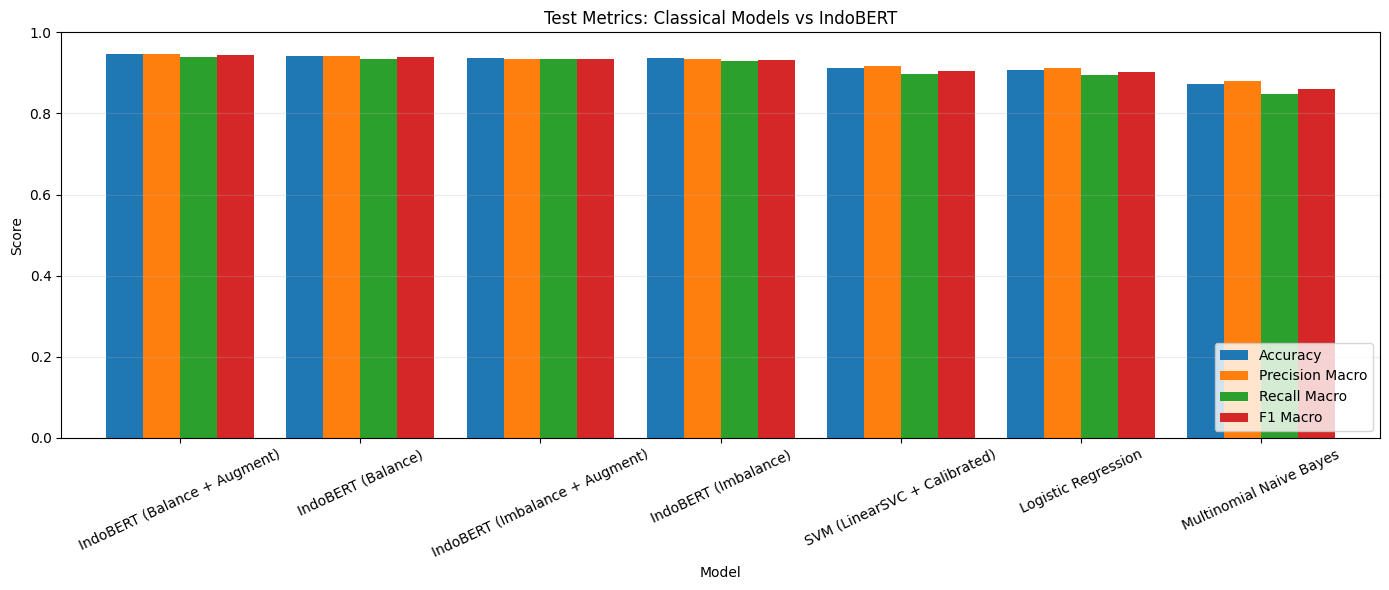

Saved: /content/drive/MyDrive/NLPAOL_V3/outputs_compare_modelresults/all_model_metrics.png


In [37]:
metrics = [
    "Accuracy",
    "Precision Macro",
    "Recall Macro",
    "F1 Macro",
]

plot_frame = comparison_df.set_index("Model")[metrics]

axis = plot_frame.plot(
    kind="bar",
    figsize=(14, 6),
    width=0.82,
)

axis.set_title("Test Metrics: Classical Models vs IndoBERT")
axis.set_xlabel("Model")
axis.set_ylabel("Score")
axis.set_ylim(0.0, 1.0)
axis.tick_params(axis="x", rotation=25)
axis.legend(loc="lower right")
axis.grid(axis="y", alpha=0.25)

plt.tight_layout()

metric_chart_path = OUTPUT_DIR / "all_model_metrics.png"
plt.savefig(metric_chart_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", metric_chart_path)

## 9. Macro F1 Ranking

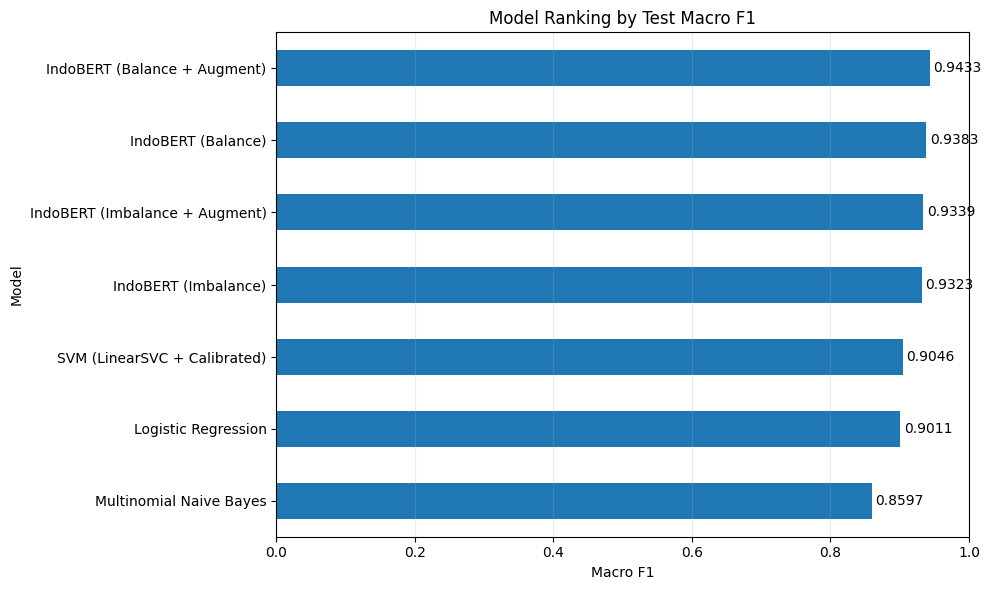

Saved: /content/drive/MyDrive/NLPAOL_V3/outputs_compare_modelresults/macro_f1_ranking.png


In [38]:
ranking_frame = (
    comparison_df[["Model", "F1 Macro"]]
    .dropna()
    .sort_values("F1 Macro", ascending=True)
    .set_index("Model")
)

axis = ranking_frame.plot(
    kind="barh",
    figsize=(10, 6),
    legend=False,
)

axis.set_title("Model Ranking by Test Macro F1")
axis.set_xlabel("Macro F1")
axis.set_ylabel("Model")
axis.set_xlim(0.0, 1.0)
axis.grid(axis="x", alpha=0.25)

for patch in axis.patches:
    value = patch.get_width()
    axis.text(
        value + 0.005,
        patch.get_y() + patch.get_height() / 2,
        f"{value:.4f}",
        va="center",
    )

plt.tight_layout()

ranking_chart_path = OUTPUT_DIR / "macro_f1_ranking.png"
plt.savefig(ranking_chart_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", ranking_chart_path)

## 10. Confusion Matrices

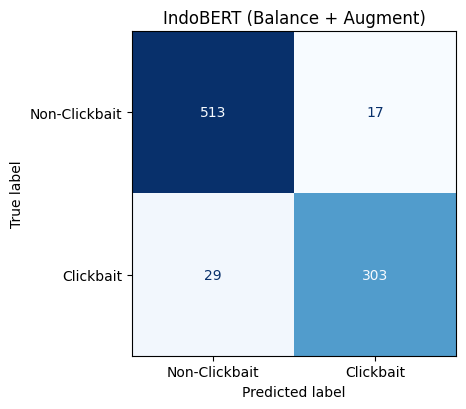

Saved: /content/drive/MyDrive/NLPAOL_V3/outputs_compare_modelresults/confusion_matrices/indobert_balance_augment.png


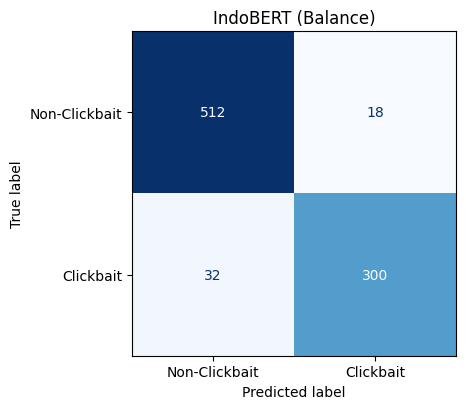

Saved: /content/drive/MyDrive/NLPAOL_V3/outputs_compare_modelresults/confusion_matrices/indobert_balance.png


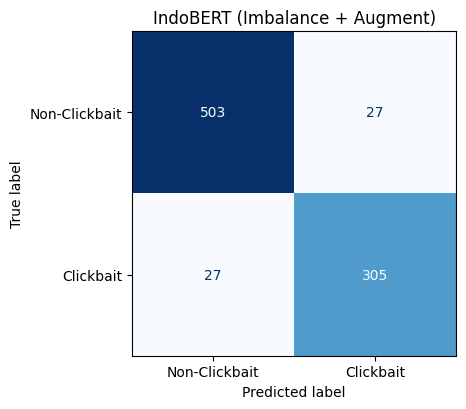

Saved: /content/drive/MyDrive/NLPAOL_V3/outputs_compare_modelresults/confusion_matrices/indobert_imbalance_augment.png


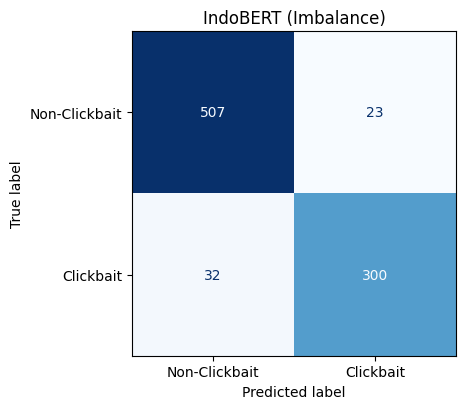

Saved: /content/drive/MyDrive/NLPAOL_V3/outputs_compare_modelresults/confusion_matrices/indobert_imbalance.png


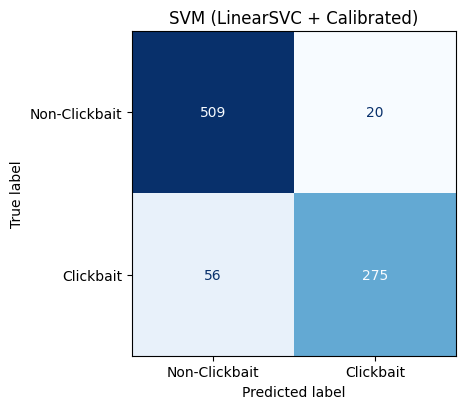

Saved: /content/drive/MyDrive/NLPAOL_V3/outputs_compare_modelresults/confusion_matrices/svm_linearsvc_calibrated.png


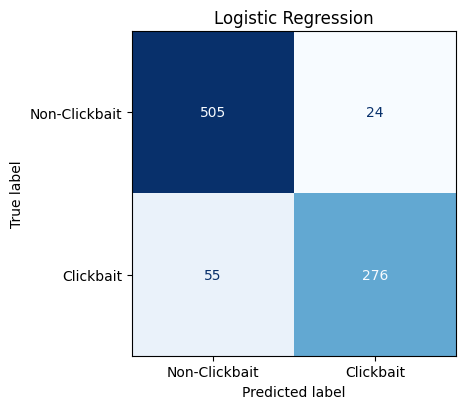

Saved: /content/drive/MyDrive/NLPAOL_V3/outputs_compare_modelresults/confusion_matrices/logistic_regression.png


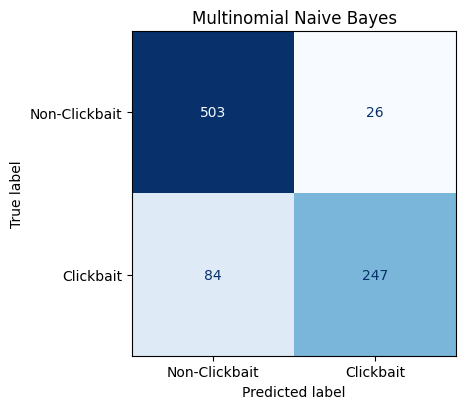

Saved: /content/drive/MyDrive/NLPAOL_V3/outputs_compare_modelresults/confusion_matrices/multinomial_naive_bayes.png
Generated 7 confusion-matrix figures.


In [39]:
confusion_output_dir = OUTPUT_DIR / "confusion_matrices"
confusion_output_dir.mkdir(parents=True, exist_ok=True)

available_count = 0

for row in comparison_rows:
    cm = validate_cm(row.get("Confusion Matrix"))

    if cm is None:
        print("Confusion matrix unavailable:", row["Model"])
        continue

    available_count += 1

    figure, axis = plt.subplots(figsize=(4.8, 4.2))

    display_matrix = ConfusionMatrixDisplay(
        confusion_matrix=np.asarray(cm),
        display_labels=["Non-Clickbait", "Clickbait"],
    )

    display_matrix.plot(
    ax=axis,
    cmap="Blues",
    colorbar=False,
    values_format="d",
)

    axis.set_title(row["Model"])
    plt.tight_layout()

    output_path = (
        confusion_output_dir
        / f"{safe_filename(row['Model'])}.png"
    )
    plt.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved:", output_path)

print(f"Generated {available_count} confusion-matrix figures.")

## 11. IndoBERT Selection and Training History

In [40]:
indobert_rows = [
    row
    for row in comparison_rows
    if row["Family"] == "IndoBERT"
]

with_validation = [
    row
    for row in indobert_rows
    if row["Validation Macro F1"] is not None
]

if with_validation:
    selected_indobert = max(
        with_validation,
        key=lambda item: item["Validation Macro F1"],
    )
    selection_reason = "highest validation macro F1"
else:
    selected_indobert = max(
        indobert_rows,
        key=lambda item: (
            item["F1 Macro"]
            if item["F1 Macro"] is not None
            else -1
        ),
    )
    selection_reason = (
        "validation score unavailable; test macro F1 used "
        "for visualization only"
    )

# This is the checkpoint with the strongest VALIDATION macro F1.
# It is a diagnostic pick (used only for the training-history charts
# below) and is NOT the final deployed Narasi model.
best_validation_indobert = selected_indobert
BEST_VALIDATION_EXPERIMENT = best_validation_indobert["Experiment"]

print("Best-by-validation experiment (diagnostic only, NOT the final model):")
print("  Experiment   :", BEST_VALIDATION_EXPERIMENT)
print("  Selection rule:", selection_reason)
print(
    "  Validation macro F1:",
    format_score(best_validation_indobert["Validation Macro F1"]),
)

Best-by-validation experiment (diagnostic only, NOT the final model):
  Experiment   : indobert_balance
  Selection rule: highest validation macro F1
  Validation macro F1: 0.9570


In [41]:
experiment_dir = (
    INDOBERT_CHECKPOINT_ROOT
    / BEST_VALIDATION_EXPERIMENT
)

state_files = []

if experiment_dir.exists():
    state_files = list(
        experiment_dir.rglob("trainer_state.json")
    )

history = []

if state_files:
    def history_length(path):
        try:
            state = json.loads(
                path.read_text(encoding="utf-8")
            )
            return len(state.get("log_history", []))
        except Exception:
            return -1

    state_file = max(
        state_files,
        key=history_length,
    )

    state = json.loads(
        state_file.read_text(encoding="utf-8")
    )

    history = [
        entry
        for entry in state.get("log_history", [])
        if "eval_loss" in entry
    ]

    print("Training state:", state_file)
    print("Evaluation entries:", len(history))
else:
    print(
        "trainer_state.json was not found for",
        BEST_VALIDATION_EXPERIMENT,
    )

Training state: /content/drive/MyDrive/NLPAOL_V3/output_indobert_final/checkpoints/indobert_balance/checkpoint-3710/trainer_state.json
Evaluation entries: 7


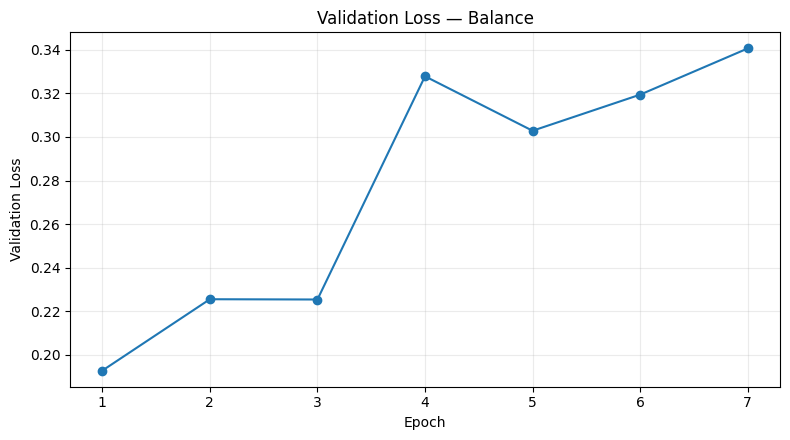

Saved: /content/drive/MyDrive/NLPAOL_V3/outputs_compare_modelresults/validation_loss_indobert_balance.png


In [42]:
if history:
    epochs = [
        entry.get("epoch", index + 1)
        for index, entry in enumerate(history)
    ]
    losses = [
        entry.get("eval_loss")
        for entry in history
    ]

    figure, axis = plt.subplots(figsize=(8, 4.5))
    axis.plot(epochs, losses, marker="o")
    axis.set_title(
        f"Validation Loss — {SETTING_LABELS.get(BEST_VALIDATION_EXPERIMENT, BEST_VALIDATION_EXPERIMENT)}"
    )
    axis.set_xlabel("Epoch")
    axis.set_ylabel("Validation Loss")
    axis.grid(alpha=0.25)

    plt.tight_layout()

    loss_path = (
        OUTPUT_DIR
        / f"validation_loss_{BEST_VALIDATION_EXPERIMENT}.png"
    )
    plt.savefig(loss_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved:", loss_path)
else:
    print("Validation-loss history is unavailable.")

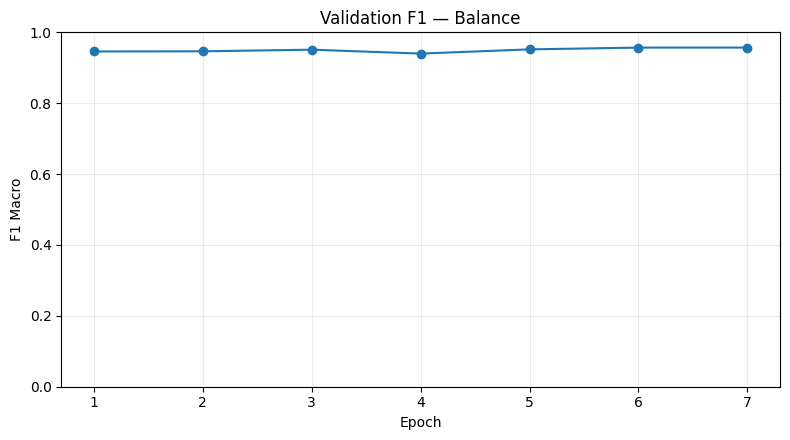

Saved: /content/drive/MyDrive/NLPAOL_V3/outputs_compare_modelresults/validation_f1_indobert_balance.png


In [43]:
if history:
    f1_key = next(
        (
            key
            for key in [
                "eval_f1_macro",
                "eval_f1",
                "eval_f1_weighted",
            ]
            if any(key in entry for entry in history)
        ),
        None,
    )

    if f1_key is not None:
        epochs = [
            entry.get("epoch", index + 1)
            for index, entry in enumerate(history)
        ]
        f1_values = [
            entry.get(f1_key)
            for entry in history
        ]

        figure, axis = plt.subplots(figsize=(8, 4.5))
        axis.plot(epochs, f1_values, marker="o")
        axis.set_title(
            f"Validation F1 — {SETTING_LABELS.get(BEST_VALIDATION_EXPERIMENT, BEST_VALIDATION_EXPERIMENT)}"
        )
        axis.set_xlabel("Epoch")
        axis.set_ylabel(f1_key.replace("eval_", "").replace("_", " ").title())
        axis.set_ylim(0.0, 1.0)
        axis.grid(alpha=0.25)

        plt.tight_layout()

        f1_history_path = (
            OUTPUT_DIR
            / f"validation_f1_{BEST_VALIDATION_EXPERIMENT}.png"
        )
        plt.savefig(
            f1_history_path,
            dpi=200,
            bbox_inches="tight",
        )
        plt.show()

        print("Saved:", f1_history_path)
    else:
        print("No validation F1 key was found in trainer_state.json.")
else:
    print("Validation-F1 history is unavailable.")

## 12. Final Summary

In [44]:
classical_rows = [
    row
    for row in comparison_rows
    if row["Family"] == "Classical"
]

best_classical = (
    max(
        classical_rows,
        key=lambda item: (
            item["F1 Macro"]
            if item["F1 Macro"] is not None
            else -1
        ),
    )
    if classical_rows
    else None
)

best_indobert_test = (
    max(
        indobert_rows,
        key=lambda item: (
            item["F1 Macro"]
            if item["F1 Macro"] is not None
            else -1
        ),
    )
    if indobert_rows
    else None
)

best_overall_test = (
    max(
        comparison_rows,
        key=lambda item: (
            item["F1 Macro"]
            if item["F1 Macro"] is not None
            else -1
        ),
    )
    if comparison_rows
    else None
)

separator = "=" * 76

print(separator)
print("FINAL MODEL COMPARISON")
print(separator)

if best_classical:
    print()
    print("Best classical model by test macro F1")
    print("  Model     :", best_classical["Model"])
    print("  Accuracy  :", format_score(best_classical["Accuracy"]))
    print("  Macro F1  :", format_score(best_classical["F1 Macro"]))

# The final deployed Narasi model is chosen by HELD-OUT TEST macro F1,
# matching the rule stated in the paper (Section 3.6): the model with
# the strongest test macro F1 is selected for deployment, even though
# a different experiment may have scored higher on validation.
final_deployed_indobert = best_indobert_test
FINAL_DEPLOYED_EXPERIMENT = (
    final_deployed_indobert["Experiment"]
    if final_deployed_indobert
    else None
)

if best_validation_indobert:
    print()
    print("Best validation strategy (diagnostic only)")
    print("  Model     :", best_validation_indobert["Model"])
    print(
        "  Val F1    :",
        format_score(best_validation_indobert["Validation Macro F1"]),
    )
    print("  Test F1   :", format_score(best_validation_indobert["F1 Macro"]))

if best_indobert_test:
    print()
    print("Highest held-out test performance among IndoBERT variants")
    print("  Model     :", best_indobert_test["Model"])
    print("  Accuracy  :", format_score(best_indobert_test["Accuracy"]))
    print("  Macro F1  :", format_score(best_indobert_test["F1 Macro"]))

if final_deployed_indobert:
    print()
    print("FINAL DEPLOYED NARASI MODEL")
    print("  Model     :", final_deployed_indobert["Model"])
    print("  Accuracy  :", format_score(final_deployed_indobert["Accuracy"]))
    print("  Macro F1  :", format_score(final_deployed_indobert["F1 Macro"]))

if best_overall_test:
    print()
    print("Highest overall test macro F1 (across all families)")
    print("  Model     :", best_overall_test["Model"])
    print("  Macro F1  :", format_score(best_overall_test["F1 Macro"]))

print()
print("Complete ranking by test macro F1")

for rank, row in enumerate(comparison_rows, start=1):
    print(
        f"  {rank}. {row['Model']:<45} "
        f"F1={format_score(row['F1 Macro'])} "
        f"Acc={format_score(row['Accuracy'])}"
    )

print()
print("Interpretation note:")
print(
    "- Validation macro F1 is used only to diagnose training stability, "
    "not to pick the final model."
)
print(
    "- The final deployed Narasi model is the IndoBERT variant with the "
    "highest held-out test macro F1 (matches the paper's Section 3.6 rule)."
)
print(
    "- Because preprocessing differs between notebooks 01 and 02, "
    "the comparison is not sample-by-sample."
)

FINAL MODEL COMPARISON

Best classical model by test macro F1
  Model     : SVM (LinearSVC + Calibrated)
  Accuracy  : 0.9116
  Macro F1  : 0.9046

Best validation strategy (diagnostic only)
  Model     : IndoBERT (Balance)
  Val F1    : 0.9570
  Test F1   : 0.9383

Highest held-out test performance among IndoBERT variants
  Model     : IndoBERT (Balance + Augment)
  Accuracy  : 0.9466
  Macro F1  : 0.9433

FINAL DEPLOYED NARASI MODEL
  Model     : IndoBERT (Balance + Augment)
  Accuracy  : 0.9466
  Macro F1  : 0.9433

Highest overall test macro F1 (across all families)
  Model     : IndoBERT (Balance + Augment)
  Macro F1  : 0.9433

Complete ranking by test macro F1
  1. IndoBERT (Balance + Augment)                  F1=0.9433 Acc=0.9466
  2. IndoBERT (Balance)                            F1=0.9383 Acc=0.9420
  3. IndoBERT (Imbalance + Augment)                F1=0.9339 Acc=0.9374
  4. IndoBERT (Imbalance)                          F1=0.9323 Acc=0.9362
  5. SVM (LinearSVC + Calibrated)   

## 13. Save Combined Results

In [45]:
csv_columns = [
    "Model",
    "Family",
    "Experiment",
    "Accuracy",
    "Precision Macro",
    "Recall Macro",
    "F1 Macro",
    "F1 Weighted",
    "AUC ROC",
    "Validation Macro F1",
    "Validation Weighted F1",
    "Inference ms/sample",
]

summary_csv_path = (
    OUTPUT_DIR
    / "comparison_summary_table.csv"
)
comparison_df[csv_columns].to_csv(
    summary_csv_path,
    index=False,
)

combined_output = {
    "comparison_scope": {
        "dataset": "CLICK-ID all_agree.csv",
        "ranking_metric": "test macro F1",
        "indobert_selection_metric": "validation macro F1",
        "sample_level_comparability": False,
        "reason": (
            "Notebook 01 removes duplicate and short titles, "
            "while notebook 02 keeps all non-empty titles."
        ),
    },
    "models": [
        json_ready(row)
        for row in comparison_rows
    ],
    "best_classical_by_test_macro_f1": (
        best_classical["Model"]
        if best_classical
        else None
    ),
    "best_validation_indobert_by_macro_f1": (
        best_validation_indobert["Model"]
        if best_validation_indobert
        else None
    ),
    "highest_indobert_test_macro_f1": (
        best_indobert_test["Model"]
        if best_indobert_test
        else None
    ),
    "final_deployed_narasi_model": (
        final_deployed_indobert["Model"]
        if final_deployed_indobert
        else None
    ),
    "highest_overall_test_macro_f1": (
        best_overall_test["Model"]
        if best_overall_test
        else None
    ),
}

summary_json_path = (
    OUTPUT_DIR
    / "comparison_results.json"
)

with open(
    summary_json_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        combined_output,
        file,
        indent=2,
        ensure_ascii=False,
    )

print("Saved CSV :", summary_csv_path)
print("Saved JSON:", summary_json_path)

print()
print("All generated files:")

for path in sorted(OUTPUT_DIR.rglob("*")):
    if path.is_file():
        print(" ", path.relative_to(OUTPUT_DIR))

Saved CSV : /content/drive/MyDrive/NLPAOL_V3/outputs_compare_modelresults/comparison_summary_table.csv
Saved JSON: /content/drive/MyDrive/NLPAOL_V3/outputs_compare_modelresults/comparison_results.json

All generated files:
  all_model_metrics.png
  comparison_results.json
  comparison_summary_table.csv
  confusion_matrices/indobert_balance.png
  confusion_matrices/indobert_balance_augment.png
  confusion_matrices/indobert_imbalance.png
  confusion_matrices/indobert_imbalance_augment.png
  confusion_matrices/logistic_regression.png
  confusion_matrices/multinomial_naive_bayes.png
  confusion_matrices/svm_linearsvc_calibrated.png
  macro_f1_ranking.png
  validation_f1_indobert_balance.png
  validation_loss_indobert_balance.png
